<a href="https://colab.research.google.com/github/jimenami/master_ciencia_datos/blob/main/DATA_MINING/DM2025_Clasificaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducción

En esta sesión vamos a realizaer ejercicios de clasificación con el clásico dataset del titanic. En concreto, practicaremos con los siguientes algoritmos:
*  SVC
*  LogisticRegression
*  DecisionTrees

Para realizar todos los ejercicios, mantén la misma semilla a la hora de realizar los Folds del CrossValidation para comparar los resultados.

También debes responder a unas preguntas relacionadas con la comprensión del temario.


In [1]:
import io
import pandas as pd
from google.colab import files
import numpy as np

# LogisticRegression -> https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
# SVC -> https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
# DecissionTree ->https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
# Kfold -> https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html

In [2]:
# La primera tarea será cargar el dataset del Titanic y lo guardamos en un df para poder operar con él
uploaded = files.upload()

Saving TitanicEjemplo.csv to TitanicEjemplo.csv


Una vez el archivo ha sido cargado, permanece en la nube (hasta ser expulsado por inactividad) y es accesible por los métodos de python:

Si haces click en "Archivos": 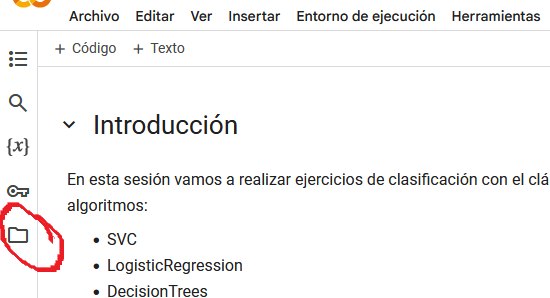

Podrás ver el nuevo archivo que has subido, listo para acceder a él:


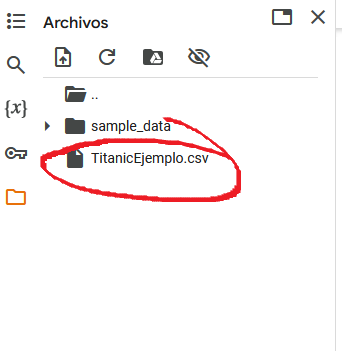

In [6]:
# Por lo que ahora ya puede ser guardado en un dataframe:
df_titanic = pd.read_csv(io.BytesIO(uploaded['TitanicEjemplo.csv']), sep=";")

In [ ]:
# Descripción de los datos
# survival	    Survival	            0 = No, 1 = Yes
# pclass	      Ticket class	        1 = 1st, 2 = 2nd, 3 = 3rd
# sex	          Sex
# Age	          Age in years
# sibsp         # of siblings / spouses aboard the Titanic
# parch	        # of parents / children aboard the Titanic
# ticket	      Ticket number
# fare	        Passenger fare
# cabin	        Cabin number
# embarked	    Port of Embarkation	  C = Cherbourg, Q = Queenstown, S = Southampton



1.   **Dale un vistazo a los datos. ¿Consideras que se podrían eliminar algunas columnas? ¿Por qué?**
2.   **¿Consideras que se podrían eliminar algunas filas? ¿Por qué?**



In [8]:
# Tamaño del dataset
np.shape(df_titanic)

(891, 12)

In [4]:
print(df_titanic.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


La columna del nombre no nos da mucha información, ya que tenemos otra columna que nos indica si los pasajeros son hombres/mujeres y que, por tanto, es más útil a la hora de hacer problemas de clasificación.

La columna del número del billete tampoco nos aporta nada, y el id del pasajero solo nos sirve como clave principal para identificarlos en nuestra base de datos, pero no es útil a nivel machine learning.

Por otro lado, las columnas de sisbp y parch podríamos agruparlas en una sola que nos indicase el nº de parientes a bordo del titanic, independientemente de que sean padres o hermanos, porque esa distinción tampoco nos aporta demasiada información.

La columna del código de la cabina tampoco parece que vaya a aportar mucha información por sí sola aunque sí que puede que sea útil para hacer análisis clúster por ejemplo que agrupe a los individuos y que posteriormente nos pueda servir para estudiar si individuos con cabinas más próximas o alejadas eran más propensos a sobrevivir o fallecer.


Aunque, cabe mencionar que, en general, las columnas a eliminar o transformar dependerán del problema que nos interese realizar.

En cuanto a las filas, podríamos eliminar aquellas con valores vacíos, aunque algunos puntuales podríamos imputarlos.

In [10]:
# Eliminamos las filas que tienen todas las columnas vacías y las filas dupllicadas
df_titanic.drop_duplicates(inplace=True)
df_titanic.dropna(how='all', inplace=True)
np.shape(df_titanic)


(891, 12)

## Ejercicio 1: Algoritmo SVC

1. Prepara los datos y realiza un modelo de clasificación basado en SVC, con el
escalador MinMax. Cross-valida los resultados para un kfold=5. Prueba distintos kernels (rbf, linear y poly) y compara los resultados.
1.   Realiza un modelo de clasificación basado en SVC, con el escalador RobustScaler. Cross-valida los resultados para un kfold=5. Prueba distintos kernels (rbf, linear y poly) y compara los resultados.

Tras realizar las operaciones de preprocesado de datos para el algoritmos SVC, deberíaas de haber obtenido un dataset similar a este:

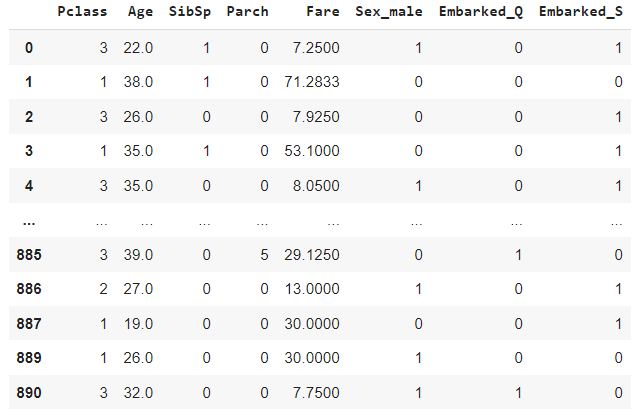


3.   **En dicho dataset, se ha realizado una operación de one-hot-encoding sobre la variable de Embarked, pero no sobre la de Pclass (que realmente también corresponden a etiquetas discretas, que van de 1 a 3). ¿Por qué? ¿Por qué no podríamos haber sustituido las etiquestas de Q,S,C por los números 1,2,3 y dejarlo como la columna Pclass?**
4.   **Además, por qué Embarked tiene únicamente 2 columnas, cuando tal como se puede ver en la descripción de los datos, podría tener 3 valores de etiqueta (Q, S, C)?**

## SVC
Para realizar el SVC necesito trabajar con variables binarias o numéricas.
Por ello voy a eliminar las columnas de nombre, cabina, número de ticket e id del pasajero.

La variable binaria sexo la voy a transofrmar dando los valores 0 para el hombre y 1 para la mujer.
Y a la variable Embarked le vamos a hacer un "one-hot-encoding" de forma que cada categoría se convierta en una categoría.



In [ ]:
df_titanic.drop('Name','Cabin', 'PassengerId','Ticket',)

## Ejercicio 2: Algoritmo LogisticRegression

1.   Realiza un modelo de clasificación basado en LinearRegression, con el escalador MinMax. Cross-valida los resultados para un kfold=5. Obtén los coeficientes de las variables de cualquier iteración.
2.   Realiza un modelo de clasificación basado en LinearRegression, con el escalador RobustScaler. Cross-valida los resultados para un kfold=5. Obtén los coeficientes de las variables de cualquier iteración.







5.   **¿Qué información/explicabilidad se puede extraer de los modelos?¿Como interpretas los resultados?**



## Ejercicio 3: DecisionTree (1/2)

1.   Realiza un modelo de clasificación basado en DecisionTree, con el escalador MinMax. Cross-valida los resultados para un kfold=5.
1.   Realiza un modelo de clasificación basado en DecisionTree, con el escalador RobustScaler. Cross-valida los resultados para un kfold=5.
1.   Realiza un modelo de clasificación basado en DecisionTree, sin escalador. Cross-valida los resultados para un kfold=5.

**6. Compara los 3 resultados de los tres algoritmos de DecisionTree? ¿Qué ocurre? ¿Por qué está pasando eso?**

## Ejercicio 4: DecisionTree (2/2)

1.   Construye dos modelos de clasificación basados en DecisionTree (sin escalador). Calcula el número de hojas y de niveles del árbol. A continuación poda el árbol a 5 niveles y compara los resultados con el árbol completo.

Tienes un trozo de código que te ayudará a dibujar el árbol, y te aparecerá un archivo en PDF en el directorio del COLAB que podrás descargar para visualizar.

In [ ]:
# Para dibujar el árbol
from sklearn import tree
# Para guardar el árbol con una resolución que se pueda ver
import matplotlib.pyplot as plt

# "model" la variable que tiene el modelo de ML que quieres dibujar

tree.plot_tree(model)
plt.savefig('Nombre_del_archivo.pdf')

**7.   ¿A qué dimensiones se le da más importancia?¿Coinciden con las dimensiones de LogisticRegression?**

**8.   Dale un vistazo a las últimas hojas del árbol sin límite¿Tienen alguna importancia?¿Aportan información relevante al modelo de ML?**